In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Admin\Downloads\youtube-viral-forecasting\data\USvideos.csv")

print(df.shape)

(40949, 16)


In [2]:
df.columns

Index(['video_id', 'trending_date', 'title', 'channel_title', 'category_id',
       'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count',
       'thumbnail_link', 'comments_disabled', 'ratings_disabled',
       'video_error_or_removed', 'description'],
      dtype='str')

In [3]:
print("\nFirst 5 Rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nUnique Videos:", df["video_id"].nunique())

print("\nNumerical Summary:")
print(df.describe())


First 5 Rows:
      video_id trending_date  \
0  2kyS6SvSYSE      17.14.11   
1  1ZAPwfrtAFY      17.14.11   
2  5qpjK5DgCt4      17.14.11   
3  puqaWrEC7tY      17.14.11   
4  d380meD0W0M      17.14.11   

                                               title          channel_title  \
0                 WE WANT TO TALK ABOUT OUR MARRIAGE           CaseyNeistat   
1  The Trump Presidency: Last Week Tonight with J...        LastWeekTonight   
2  Racist Superman | Rudy Mancuso, King Bach & Le...           Rudy Mancuso   
3                   Nickelback Lyrics: Real or Fake?  Good Mythical Morning   
4                           I Dare You: GOING BALD!?               nigahiga   

   category_id              publish_time  \
0           22  2017-11-13T17:13:01.000Z   
1           24  2017-11-13T07:30:00.000Z   
2           23  2017-11-12T19:05:24.000Z   
3           24  2017-11-13T11:00:04.000Z   
4           24  2017-11-12T18:01:41.000Z   

                                                tags

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   video_id                40949 non-null  str  
 1   trending_date           40949 non-null  str  
 2   title                   40949 non-null  str  
 3   channel_title           40949 non-null  str  
 4   category_id             40949 non-null  int64
 5   publish_time            40949 non-null  str  
 6   tags                    40949 non-null  str  
 7   views                   40949 non-null  int64
 8   likes                   40949 non-null  int64
 9   dislikes                40949 non-null  int64
 10  comment_count           40949 non-null  int64
 11  thumbnail_link          40949 non-null  str  
 12  comments_disabled       40949 non-null  bool 
 13  ratings_disabled        40949 non-null  bool 
 14  video_error_or_removed  40949 non-null  bool 
 15  description             40379 

In [5]:
import pandas as pd

# Load dataset
df = pd.read_csv(
    r"C:\Users\Admin\Downloads\youtube-viral-forecasting\data\USvideos.csv"
)

# Convert date/time columns
df["trending_date"] = pd.to_datetime(
    df["trending_date"],
    format="%y.%d.%m"
)

df["publish_time"] = pd.to_datetime(
    df["publish_time"],
    utc=True
).dt.tz_localize(None)

# Remove unnecessary columns
df = df.drop(columns=[
    "thumbnail_link",
    "description"
])

# Create time-based features
df["publish_hour"] = df["publish_time"].dt.hour
df["publish_day"] = df["publish_time"].dt.dayofweek
df["publish_month"] = df["publish_time"].dt.month

# Calculate days between publishing and trending
df["days_to_trend"] = (
    df["trending_date"] - df["publish_time"].dt.normalize()
).dt.days

# Remove invalid records
df = df[df["days_to_trend"] >= 0].copy()

# Check result
print("Shape after cleaning:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nSample:")
print(df[[
    "video_id",
    "trending_date",
    "publish_time",
    "days_to_trend",
    "publish_hour",
    "publish_day",
    "publish_month",
    "views",
    "likes",
    "comment_count"
]].head())

Shape after cleaning: (40949, 18)

Missing values:
video_id                  0
trending_date             0
title                     0
channel_title             0
category_id               0
publish_time              0
tags                      0
views                     0
likes                     0
dislikes                  0
comment_count             0
comments_disabled         0
ratings_disabled          0
video_error_or_removed    0
publish_hour              0
publish_day               0
publish_month             0
days_to_trend             0
dtype: int64

Sample:
      video_id trending_date        publish_time  days_to_trend  publish_hour  \
0  2kyS6SvSYSE    2017-11-14 2017-11-13 17:13:01              1            17   
1  1ZAPwfrtAFY    2017-11-14 2017-11-13 07:30:00              1             7   
2  5qpjK5DgCt4    2017-11-14 2017-11-12 19:05:24              2            19   
3  puqaWrEC7tY    2017-11-14 2017-11-13 11:00:04              1            11   
4  d380meD0W0M    

Views Statistics:
count    4.094900e+04
mean     2.360785e+06
std      7.394114e+06
min      5.490000e+02
25%      2.423290e+05
50%      6.818610e+05
75%      1.823157e+06
max      2.252119e+08
Name: views, dtype: float64

Likes Statistics:
count    4.094900e+04
mean     7.426670e+04
std      2.288853e+05
min      0.000000e+00
25%      5.424000e+03
50%      1.809100e+04
75%      5.541700e+04
max      5.613827e+06
Name: likes, dtype: float64

Comments Statistics:
count    4.094900e+04
mean     8.446804e+03
std      3.743049e+04
min      0.000000e+00
25%      6.140000e+02
50%      1.856000e+03
75%      5.755000e+03
max      1.361580e+06
Name: comment_count, dtype: float64

Correlation:
               views  likes  dislikes  comment_count
views           1.00   0.85      0.47           0.62
likes           0.85   1.00      0.45           0.80
dislikes        0.47   0.45      1.00           0.70
comment_count   0.62   0.80      0.70           1.00


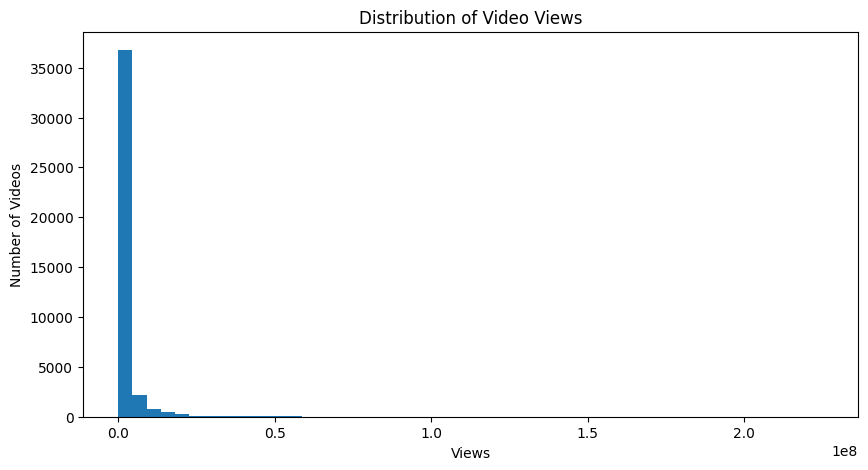

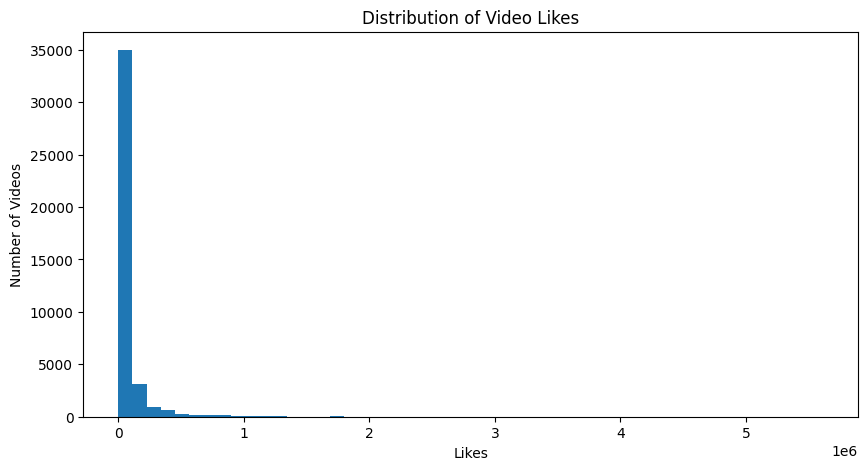

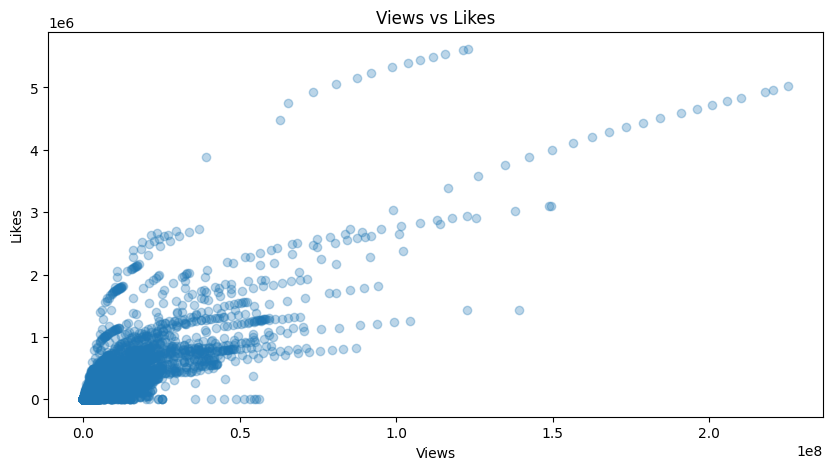

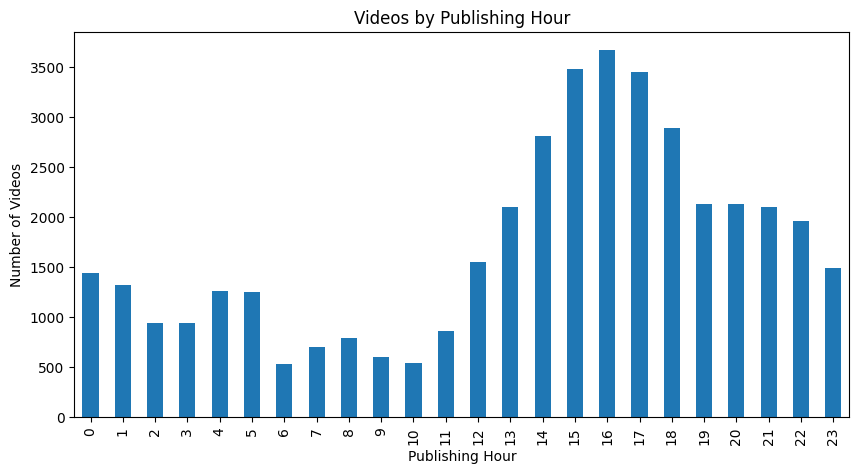

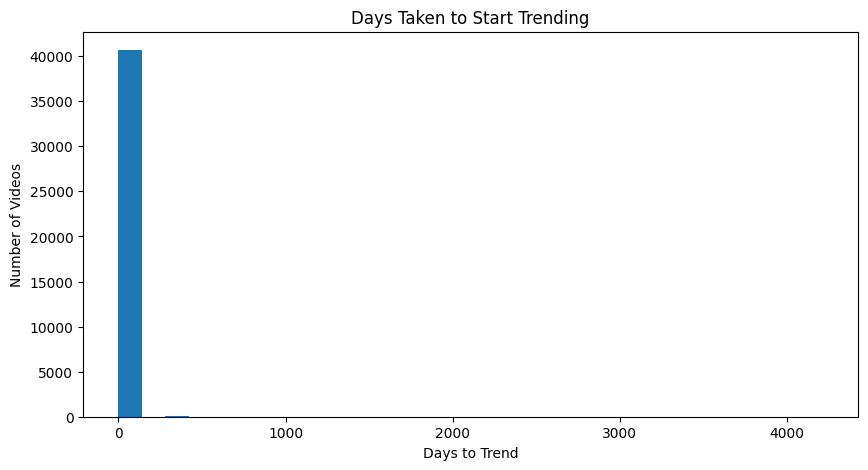

In [6]:
import matplotlib.pyplot as plt

# Basic statistics
print("Views Statistics:")
print(df["views"].describe())

print("\nLikes Statistics:")
print(df["likes"].describe())

print("\nComments Statistics:")
print(df["comment_count"].describe())

# Correlation
print("\nCorrelation:")
print(
    df[["views", "likes", "dislikes", "comment_count"]]
    .corr()
    .round(2)
)

# Views distribution
plt.figure(figsize=(10, 5))
plt.hist(df["views"], bins=50)
plt.title("Distribution of Video Views")
plt.xlabel("Views")
plt.ylabel("Number of Videos")
plt.show()

# Likes distribution
plt.figure(figsize=(10, 5))
plt.hist(df["likes"], bins=50)
plt.title("Distribution of Video Likes")
plt.xlabel("Likes")
plt.ylabel("Number of Videos")
plt.show()

# Views vs Likes
plt.figure(figsize=(10, 5))
plt.scatter(df["views"], df["likes"], alpha=0.3)
plt.title("Views vs Likes")
plt.xlabel("Views")
plt.ylabel("Likes")
plt.show()

# Videos by publishing hour
plt.figure(figsize=(10, 5))
df["publish_hour"].value_counts().sort_index().plot(kind="bar")
plt.title("Videos by Publishing Hour")
plt.xlabel("Publishing Hour")
plt.ylabel("Number of Videos")
plt.show()

# Days to trend
plt.figure(figsize=(10, 5))
plt.hist(df["days_to_trend"], bins=30)
plt.title("Days Taken to Start Trending")
plt.xlabel("Days to Trend")
plt.ylabel("Number of Videos")
plt.show()

In [7]:
# =========================
# 5. ENGAGEMENT FEATURES
# =========================

# Avoid division by zero
df["like_rate"] = df["likes"] / df["views"].replace(0, 1)
df["comment_rate"] = df["comment_count"] / df["views"].replace(0, 1)
df["dislike_rate"] = df["dislikes"] / df["views"].replace(0, 1)

# Overall engagement rate
df["engagement_rate"] = (
    df["likes"] +
    df["dislikes"] +
    df["comment_count"]
) / df["views"].replace(0, 1)

# =========================
# 6. VIRALITY TARGET
# =========================

# Top 25% videos based on views = Viral
viral_threshold = df["views"].quantile(0.75)

df["viral"] = (
    df["views"] >= viral_threshold
).astype(int)

# =========================
# 7. CHECK RESULTS
# =========================

print("Viral View Threshold:", int(viral_threshold))

print("\nViral Distribution:")
print(df["viral"].value_counts())

print("\nViral Percentage:")
print(
    (df["viral"].value_counts(normalize=True) * 100).round(2)
)

print("\nNew Features:")
print(
    df[[
        "views",
        "likes",
        "comment_count",
        "like_rate",
        "comment_rate",
        "engagement_rate",
        "viral"
    ]].head()
)

Viral View Threshold: 1823157

Viral Distribution:
viral
0    30711
1    10238
Name: count, dtype: int64

Viral Percentage:
viral
0    75.0
1    25.0
Name: proportion, dtype: float64

New Features:
     views   likes  comment_count  like_rate  comment_rate  engagement_rate  \
0   748374   57527          15954   0.076869      0.021318         0.102151   
1  2418783   97185          12703   0.040179      0.005252         0.047972   
2  3191434  146033           8181   0.045758      0.002563         0.049994   
3   343168   10172           2146   0.029641      0.006253         0.037836   
4  2095731  132235          17518   0.063097      0.008359         0.072405   

   viral  
0      0  
1      1  
2      1  
3      0  
4      1  


In [8]:
from sklearn.model_selection import train_test_split

# =========================
# 1. SELECT FEATURES
# =========================

features = [
    "category_id",
    "publish_hour",
    "publish_day",
    "publish_month",
    "days_to_trend",
    "comments_disabled",
    "ratings_disabled",
    "video_error_or_removed"
]

X = df[features]
y = df["viral"]

# =========================
# 2. TRAIN-TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# =========================
# 3. CHECK DATA
# =========================

print("Total samples:", len(df))

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

print("\nFeatures used:")
print(X.columns.tolist())

Total samples: 40949

Training samples: 32759
Testing samples: 8190

Training target distribution:
viral
0    24569
1     8190
Name: count, dtype: int64

Testing target distribution:
viral
0    6142
1    2048
Name: count, dtype: int64

Features used:
['category_id', 'publish_hour', 'publish_day', 'publish_month', 'days_to_trend', 'comments_disabled', 'ratings_disabled', 'video_error_or_removed']


In [9]:
# =========================
# 7. VIDEO-LEVEL FORECASTING DATASET
# =========================

import pandas as pd

# Reload original cleaned dataset
df = pd.read_csv(
    r"C:\Users\Admin\Downloads\youtube-viral-forecasting\data\USvideos.csv"
)

# Date conversion
df["trending_date"] = pd.to_datetime(
    df["trending_date"],
    format="%y.%d.%m"
)

df["publish_time"] = pd.to_datetime(
    df["publish_time"],
    utc=True
).dt.tz_localize(None)

# Sort so first record of each video is available
df = df.sort_values(
    ["video_id", "trending_date"]
).copy()

# -------------------------
# First trending snapshot
# -------------------------

first_snapshot = df.groupby("video_id").first().reset_index()

# -------------------------
# Future / maximum views
# -------------------------

max_views = (
    df.groupby("video_id")["views"]
    .max()
    .reset_index(name="max_views")
)

# Combine first snapshot + future maximum views
video_df = first_snapshot.merge(
    max_views,
    on="video_id"
)

# -------------------------
# Feature engineering
# -------------------------

video_df["publish_hour"] = video_df["publish_time"].dt.hour
video_df["publish_day"] = video_df["publish_time"].dt.dayofweek
video_df["publish_month"] = video_df["publish_time"].dt.month

video_df["days_to_trend"] = (
    video_df["trending_date"]
    - video_df["publish_time"].dt.normalize()
).dt.days

# Early engagement features
video_df["like_rate"] = (
    video_df["likes"] /
    video_df["views"].replace(0, 1)
)

video_df["comment_rate"] = (
    video_df["comment_count"] /
    video_df["views"].replace(0, 1)
)
video_df["engagement_rate"] = (
    video_df["likes"]
    + video_df["comment_count"]
) / video_df["views"].replace(0, 1)

# Title features
video_df["title_length"] = video_df["title"].str.len()

# Number of tags
video_df["tag_count"] = (
    video_df["tags"]
    .fillna("")
    .apply(lambda x: 0 if x == "[none]" else len(x.split("|")))
)

# -------------------------
# Create viral target
# -------------------------

viral_threshold = video_df["max_views"].quantile(0.75)

video_df["viral"] = (
    video_df["max_views"] >= viral_threshold
).astype(int)

# -------------------------
# Final information
# -------------------------

print("Video-level dataset shape:", video_df.shape)

print("\nViral threshold:",
      int(viral_threshold))

print("\nViral distribution:")
print(video_df["viral"].value_counts())

print("\nViral percentage:")
print(
    (video_df["viral"].value_counts(normalize=True) * 100)
    .round(2)
)

print("\nFinal columns:")
print(video_df.columns.tolist())

print("\nSample:")
print(
    video_df[[
        "video_id",
        "views",
        "likes",
        "comment_count",
        "max_views",
        "engagement_rate",
        "title_length",
        "tag_count",
        "viral"
    ]].head()
)

Video-level dataset shape: (6351, 27)

Viral threshold: 1474750

Viral distribution:
viral
0    4763
1    1588
Name: count, dtype: int64

Viral percentage:
viral
0    75.0
1    25.0
Name: proportion, dtype: float64

Final columns:
['video_id', 'trending_date', 'title', 'channel_title', 'category_id', 'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count', 'thumbnail_link', 'comments_disabled', 'ratings_disabled', 'video_error_or_removed', 'description', 'max_views', 'publish_hour', 'publish_day', 'publish_month', 'days_to_trend', 'like_rate', 'comment_rate', 'engagement_rate', 'title_length', 'tag_count', 'viral']

Sample:
      video_id    views  likes  comment_count  max_views  engagement_rate  \
0  -0CMnp02rNY   475965   6531            271     800359         0.014291   
1  -0NYY8cqdiQ   563746   4429             94     563746         0.008023   
2  -1Hm41N0dUs  1566807  32752           1490    2058516         0.021855   
3  -1yT-K3c6YI   129360   5214            516 

In [10]:
# =========================
# 8. TRAIN / TEST SPLIT
# =========================

from sklearn.model_selection import train_test_split

# Features available at the time of early prediction
features = [
    "views",
    "likes",
    "comment_count",
    "like_rate",
    "comment_rate",
    "engagement_rate",
    "category_id",
    "publish_hour",
    "publish_day",
    "publish_month",
    "days_to_trend",
    "comments_disabled",
    "ratings_disabled",
    "video_error_or_removed",
    "title_length",
    "tag_count"
]

X = video_df[features]
y = video_df["viral"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# -------------------------
# Check the split
# -------------------------

print("Total videos:", len(video_df))

print("\nTraining videos:", len(X_train))
print("Testing videos:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

print("\nFeatures used:")
for feature in features:
    print("-", feature)

# =========================
# 8. TEST NEW VIDEO
# =========================

new_video = pd.DataFrame([{
    "views": 100000,
    "likes": 5000,
    "comment_count": 500,

    "like_rate": 5000 / 100000,
    "comment_rate": 500 / 100000,
    "engagement_rate": (5000 + 500) / 100000,

    "category_id": 10,
    "publish_hour": 14,
    "publish_day": 2,
    "publish_month": 6,

    "comments_disabled": False,
    "ratings_disabled": False,
    "video_error_or_removed": False,

    "title_length": 50,
    "tag_count": 8
}])

prediction = best_model.predict(new_video)[0]

probability = best_model.predict_proba(new_video)[0][1]

print("\nPrediction:", "Viral" if prediction == 1 else "Not Viral")
print("Probability:", probability)
print("Probability %:", round(probability * 100, 2))

Total videos: 6351

Training videos: 5080
Testing videos: 1271

Training target distribution:
viral
0    3810
1    1270
Name: count, dtype: int64

Testing target distribution:
viral
0    953
1    318
Name: count, dtype: int64

Features used:
- views
- likes
- comment_count
- like_rate
- comment_rate
- engagement_rate
- category_id
- publish_hour
- publish_day
- publish_month
- days_to_trend
- comments_disabled
- ratings_disabled
- video_error_or_removed
- title_length
- tag_count


NameError: name 'best_model' is not defined

In [17]:
# =========================
# 9. MODEL TRAINING
# =========================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# -------------------------
# 1. Create models
# -------------------------

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

# -------------------------
# 2. Train and evaluate
# -------------------------

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])

# -------------------------
# 3. Display results
# -------------------------

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

print("\nModel Performance:")
print(
    results_df.round(4).to_string(index=False)
)

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Model Performance:
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.9150     0.8804  0.7642    0.8182   0.9490
      Random Forest    0.9174     0.8873  0.7673    0.8229   0.9596
  Gradient Boosting    0.9127     0.8606  0.7767    0.8165   0.9561


Selected Model: Logistic Regression


<Figure size 600x500 with 0 Axes>

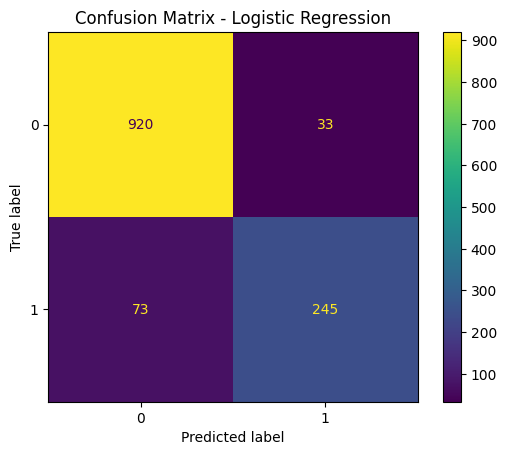

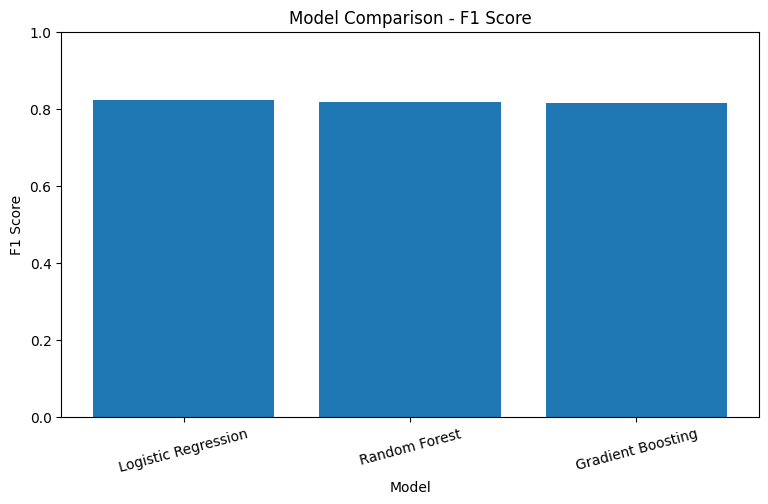


Feature importance is not directly available for this model.


In [23]:
# =========================
# 10. MODEL EVALUATION
# =========================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# -------------------------
# 1. Best model based on F1
# -------------------------

best_model_name = results_df.loc[
    results_df["F1 Score"].idxmax(), "Model"
]

best_model = models[best_model_name]

print("Selected Model:", best_model_name)

# Predictions
y_pred = best_model.predict(X_test)

# -------------------------
# 2. Confusion Matrix
# -------------------------

plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

# -------------------------
# 3. Model Comparison
# -------------------------

plt.figure(figsize=(9, 5))

plt.bar(
    results_df["Model"],
    results_df["F1 Score"]
)

plt.title("Model Comparison - F1 Score")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=15)
plt.ylim(0, 1)

plt.show()

# -------------------------
# 4. Feature Importance
# -------------------------

if hasattr(best_model, "feature_importances_"):

    importance = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": best_model.feature_importances_
    })

    importance = importance.sort_values(
        "Importance",
        ascending=False
    )

    print("\nFeature Importance:")
    print(importance.to_string(index=False))

    plt.figure(figsize=(10, 6))

    plt.barh(
        importance["Feature"],
        importance["Importance"]
    )

    plt.gca().invert_yaxis()

    plt.title(
        f"Feature Importance - {best_model_name}"
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")

    plt.show()

else:
    print(
        "\nFeature importance is not directly available "
        "for this model."
    )

In [24]:
# =========================
# 11. NEW VIDEO PREDICTION
# =========================

# Example: information available when a video
# gets its first trending snapshot

new_video = pd.DataFrame([{
    "views": 50000,
    "likes": 2500,
    "comment_count": 300,

    "like_rate": 2500 / 50000,
    "comment_rate": 300 / 50000,
    "engagement_rate": (2500 + 300) / 50000,

    "category_id": 24,
    "publish_hour": 14,
    "publish_day": 2,
    "publish_month": 9,

    "days_to_trend": 1,

    "comments_disabled": False,
    "ratings_disabled": False,
    "video_error_or_removed": False,

    "title_length": 60,
    "tag_count": 8
}])

# Make prediction
prediction = best_model.predict(new_video)[0]

probability = best_model.predict_proba(
    new_video
)[0][1]

# Display result
print("Prediction Result")
print("-----------------")

if prediction == 1:
    print("Prediction: VIRAL")
else:
    print("Prediction: NOT VIRAL")

print(
    f"Probability of becoming viral: "
    f"{probability * 100:.2f}%"
)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- days_to_trend


In [15]:
# =========================
# 12. SAVE TRAINED MODEL
# =========================

import os
import joblib

# Create models folder
os.makedirs(
    r"C:\Users\Admin\Downloads\youtube-viral-forecasting\models",
    exist_ok=True
)

# Save best model
model_path = (
    r"C:\Users\Admin\Downloads\youtube-viral-forecasting"
    r"\models\viral_video_model.pkl"
)

joblib.dump(
    best_model,
    model_path
)

# Save feature names
features_path = (
    r"C:\Users\Admin\Downloads\youtube-viral-forecasting"
    r"\models\features.pkl"
)

joblib.dump(
    features,
    features_path
)

print("Model saved successfully!")
print("Model:", model_path)
print("Features:", features_path)

# Check by loading the model again
loaded_model = joblib.load(model_path)

print("\nModel loaded successfully!")
print("Model type:", type(loaded_model).__name__)

Model saved successfully!
Model: C:\Users\Admin\Downloads\youtube-viral-forecasting\models\viral_video_model.pkl
Features: C:\Users\Admin\Downloads\youtube-viral-forecasting\models\features.pkl

Model loaded successfully!
Model type: GradientBoostingClassifier


In [22]:
# =========================
# CORRECTED MODEL TRAINING
# =========================

import os
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# =========================
# 1. FEATURES
# =========================

# Only information available at early prediction time
features = [
    "views",
    "likes",
    "comment_count",
    "like_rate",
    "comment_rate",
    "engagement_rate",
    "category_id",
    "publish_hour",
    "publish_day",
    "publish_month",
    "comments_disabled",
    "ratings_disabled",
    "video_error_or_removed",
    "title_length",
    "tag_count"
]

X = video_df[features]
y = video_df["viral"]

# =========================
# 2. TRAIN / TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# =========================
# 3. MODELS
# =========================

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

# =========================
# 4. TRAIN + EVALUATE
# =========================

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

print("\nModel Performance:")
print(results_df.round(4).to_string(index=False))

# =========================
# 5. SELECT BEST MODEL
# =========================

best_model_name = results_df.loc[
    results_df["F1 Score"].idxmax(),
    "Model"
]

best_model = models[best_model_name]

print("\nSelected Model:", best_model_name)

# =========================
# 6. SAVE MODEL
# =========================

model_folder = (
    r"C:\Users\Admin\Downloads"
    r"\youtube-viral-forecasting\models"
)

os.makedirs(model_folder, exist_ok=True)

joblib.dump(
    best_model,
    os.path.join(
        model_folder,
        "viral_video_model.pkl"
    )
)

joblib.dump(
    features,
    os.path.join(
        model_folder,
        "features.pkl"
    )
)

print("\nModel saved successfully.")
print("Features saved successfully.")

# =========================
# 7. CHECK
# =========================

print("\nFeatures used by final model:")
for feature in features:
    print("-", feature)

Training samples: 5080
Testing samples: 1271


c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Model Performance:
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.9166     0.8813  0.7704    0.8221   0.9486
      Random Forest    0.9158     0.8951  0.7516    0.8171   0.9573
  Gradient Boosting    0.9127     0.8657  0.7704    0.8153   0.9558

Selected Model: Logistic Regression

Model saved successfully.
Features saved successfully.

Features used by final model:
- views
- likes
- comment_count
- like_rate
- comment_rate
- engagement_rate
- category_id
- publish_hour
- publish_day
- publish_month
- comments_disabled
- ratings_disabled
- video_error_or_removed
- title_length
- tag_count
